<a href="https://colab.research.google.com/github/deepayansinha/realistic-heterogeneity-intermittent-connectivity/blob/main/notebooks/06_dp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NOTEBOOK 06
# DIFFERENTIAL PRIVACY FEDERATED LEARNING
# ============================================================

"""
Notebook 06

Objective

Integrate Differential Privacy into
Federated Learning using Opacus.

Pipeline

Load Dataset

↓

Load Client Partitions

↓

Attach Privacy Engine

↓

Train DP Local Models

↓

FedAvg Aggregation

↓

Track Privacy Budget

↓

Evaluate Accuracy

↓

Save Results
"""

print("="*60)
print("NOTEBOOK 06")
print("DIFFERENTIAL PRIVACY FEDERATED LEARNING")
print("="*60)

NOTEBOOK 06
DIFFERENTIAL PRIVACY FEDERATED LEARNING


In [4]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import copy
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader
from torch.utils.data import Subset

!pip install opacus
from opacus import PrivacyEngine

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)
print("Device :",device)
print("="*60)

Device : cuda


In [6]:
# ============================================================
# LOAD DATASET
# ============================================================

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )

])

trainset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("="*60)
print("Training :",len(trainset))
print("Testing  :",len(testset))
print("="*60)

100%|██████████| 170M/170M [39:26<00:00, 72.1kB/s]


Training : 50000
Testing  : 10000


In [8]:
# ============================================================
# LOAD OR CREATE NON-IID PARTITIONS
# ============================================================

PARTITION_DIR = "saved_partitions"

os.makedirs(PARTITION_DIR, exist_ok=True)

NONIID_FILE = os.path.join(
    PARTITION_DIR,
    "noniid_clients.pkl"
)

NUM_CLIENTS = 10
ALPHA = 0.3

if os.path.exists(NONIID_FILE):

    print("Loading saved Non-IID partitions...")

    with open(NONIID_FILE, "rb") as f:
        noniid_clients = pickle.load(f)

else:

    print("Creating Non-IID partitions...")

    def dirichlet_partition(targets,
                            num_clients,
                            alpha):

        targets = np.array(targets)

        client_indices = [[] for _ in range(num_clients)]

        for cls in np.unique(targets):

            cls_idx = np.where(targets == cls)[0]

            np.random.shuffle(cls_idx)

            proportions = np.random.dirichlet(
                np.repeat(alpha, num_clients)
            )

            split = np.split(
                cls_idx,
                (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
            )

            for i, idx in enumerate(split):
                client_indices[i].extend(idx)

        return client_indices

    noniid_clients = dirichlet_partition(
        trainset.targets,
        NUM_CLIENTS,
        ALPHA
    )

    with open(NONIID_FILE, "wb") as f:
        pickle.dump(noniid_clients, f)

print("=" * 60)
print("Clients:", len(noniid_clients))
print("=" * 60)

Creating Non-IID partitions...
Clients: 10


In [9]:
# ============================================================
# CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),

            nn.Linear(512, 10)

        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


print(CNN())

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [10]:
# ============================================================
# INITIALIZE GLOBAL MODEL
# ============================================================

global_model = CNN().to(device)

print("=" * 60)
print("Global CNN initialized.")
print("=" * 60)

Global CNN initialized.


In [11]:
# ============================================================
# CLIENT DATALOADERS
# ============================================================

client_loaders = []

for client in range(NUM_CLIENTS):

    subset = Subset(
        trainset,
        noniid_clients[client]
    )

    loader = DataLoader(
        subset,
        batch_size=64,
        shuffle=True
    )

    client_loaders.append(loader)

print("=" * 60)
print(f"Created {len(client_loaders)} client dataloaders.")
print("=" * 60)

Created 10 client dataloaders.


In [12]:
# ============================================================
# TEST LOADER & EVALUATION
# ============================================================

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)


def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(1)

            total += labels.size(0)

            correct += (predictions == labels).sum().item()

    return 100 * correct / total


print("Evaluation function ready.")

Evaluation function ready.


In [13]:
# ============================================================
# DIFFERENTIAL PRIVACY SETTINGS
# ============================================================

MAX_GRAD_NORM = 1.0
NOISE_MULTIPLIER = 1.1
DELTA = 1e-5

ROUNDS = 10
LOCAL_EPOCHS = 1

print("=" * 60)
print("Differential Privacy Configuration")
print(f"Noise Multiplier : {NOISE_MULTIPLIER}")
print(f"Max Grad Norm    : {MAX_GRAD_NORM}")
print(f"Delta            : {DELTA}")
print("=" * 60)

Differential Privacy Configuration
Noise Multiplier : 1.1
Max Grad Norm    : 1.0
Delta            : 1e-05


In [19]:
# ============================================================
# DP LOCAL TRAINING
# ============================================================

def dp_local_train(model, loader, epochs=1):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    privacy_engine = PrivacyEngine()

    model.train() # Set model to training mode before making it private

    model, optimizer, loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=loader,
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM
    )

    for _ in range(epochs):

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

    epsilon = privacy_engine.get_epsilon(delta=DELTA)

    return model.state_dict(), epsilon

In [15]:
# ============================================================
# FEDERATED AVERAGING
# ============================================================

def federated_average(client_weights):

    average = copy.deepcopy(client_weights[0])

    for key in average.keys():

        for i in range(1, len(client_weights)):

            average[key] += client_weights[i][key]

        average[key] /= len(client_weights)

    return average

print("FedAvg Ready")

FedAvg Ready


In [20]:
# ============================================================
# DP FEDERATED LEARNING
# ============================================================

accuracy_history = []
epsilon_history = []

for rnd in range(ROUNDS):

    print(f"\nCommunication Round {rnd+1}/{ROUNDS}")

    client_weights = []
    epsilons = []

    for client in range(NUM_CLIENTS):

        local_model = copy.deepcopy(global_model).to(device)

        weights, eps = dp_local_train(
            local_model,
            client_loaders[client],
            LOCAL_EPOCHS
        )

        client_weights.append(weights)
        epsilons.append(eps)

    averaged_weights = federated_average(client_weights)

    # Remove '_module.' prefix from keys if present
    cleaned_averaged_weights = {
        k.replace('_module.', ''): v
        for k, v in averaged_weights.items()
    }

    global_model.load_state_dict(cleaned_averaged_weights)

    accuracy = evaluate(global_model)

    accuracy_history.append(accuracy)
    epsilon_history.append(np.mean(epsilons))

    print(f"Accuracy : {accuracy:.2f}%")
    print(f"Average ε : {np.mean(epsilons):.2f}")


Communication Round 1/10


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Accuracy : 10.38%
Average ε : 0.72

Communication Round 2/10
Accuracy : 10.37%
Average ε : 0.72

Communication Round 3/10
Accuracy : 12.46%
Average ε : 0.72

Communication Round 4/10
Accuracy : 14.15%
Average ε : 0.72

Communication Round 5/10
Accuracy : 14.88%
Average ε : 0.72

Communication Round 6/10
Accuracy : 20.24%
Average ε : 0.72

Communication Round 7/10
Accuracy : 20.75%
Average ε : 0.72

Communication Round 8/10
Accuracy : 21.05%
Average ε : 0.72

Communication Round 9/10
Accuracy : 23.74%
Average ε : 0.72

Communication Round 10/10
Accuracy : 24.07%
Average ε : 0.72


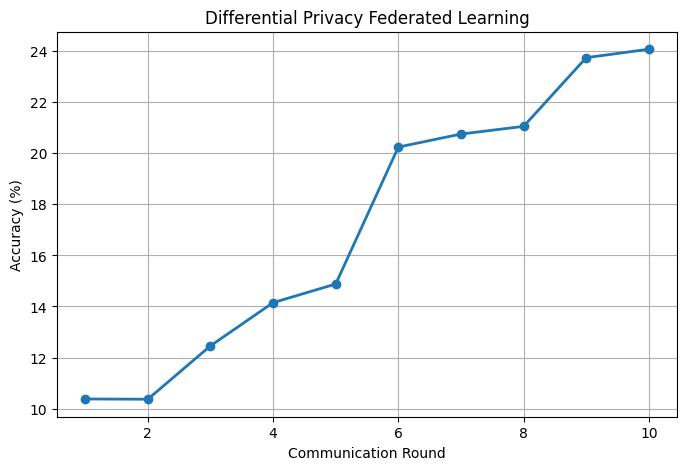

In [21]:
# ============================================================
# ACCURACY PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, ROUNDS+1),
    accuracy_history,
    marker="o",
    linewidth=2
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy (%)")
plt.title("Differential Privacy Federated Learning")

plt.grid(True)

plt.show()

In [22]:
# ============================================================
# SAVE RESULTS
# ============================================================

os.makedirs("results", exist_ok=True)

results = pd.DataFrame({

    "Round": range(1, ROUNDS+1),

    "Accuracy": accuracy_history,

    "Epsilon": epsilon_history

})

results.to_csv(
    "results/dp_federated_results.csv",
    index=False
)

torch.save(
    global_model.state_dict(),
    "results/dp_global_model.pth"
)

print(results)

   Round  Accuracy  Epsilon
0      1     10.38  0.71808
1      2     10.37  0.71808
2      3     12.46  0.71808
3      4     14.15  0.71808
4      5     14.88  0.71808
5      6     20.24  0.71808
6      7     20.75  0.71808
7      8     21.05  0.71808
8      9     23.74  0.71808
9     10     24.07  0.71808


In [23]:
# ============================================================
# SUMMARY
# ============================================================

print("="*60)
print("DIFFERENTIAL PRIVACY FEDERATED LEARNING COMPLETE")
print("="*60)

print(f"Final Accuracy : {accuracy_history[-1]:.2f}%")
print(f"Final ε        : {epsilon_history[-1]:.2f}")

print("="*60)

DIFFERENTIAL PRIVACY FEDERATED LEARNING COMPLETE
Final Accuracy : 24.07%
Final ε        : 0.72
